# Note: All the test datasets and models can be downloaded from Hugging Face Hub, please refer to the following link for more information: https://huggingface.co/datasets

## First, download models and datasets

##### Set the downloading token first:
 Note that the Hugging Face Hub requires an access token for downloading private datasets. You can obtain your token from https://huggingface.co/settings/tokens.

Click "create new token"

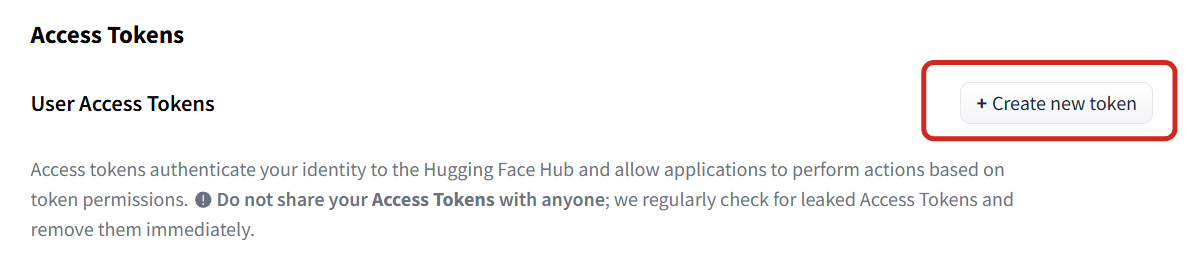

1.Select write permission

2.set the name

3.click "create token"

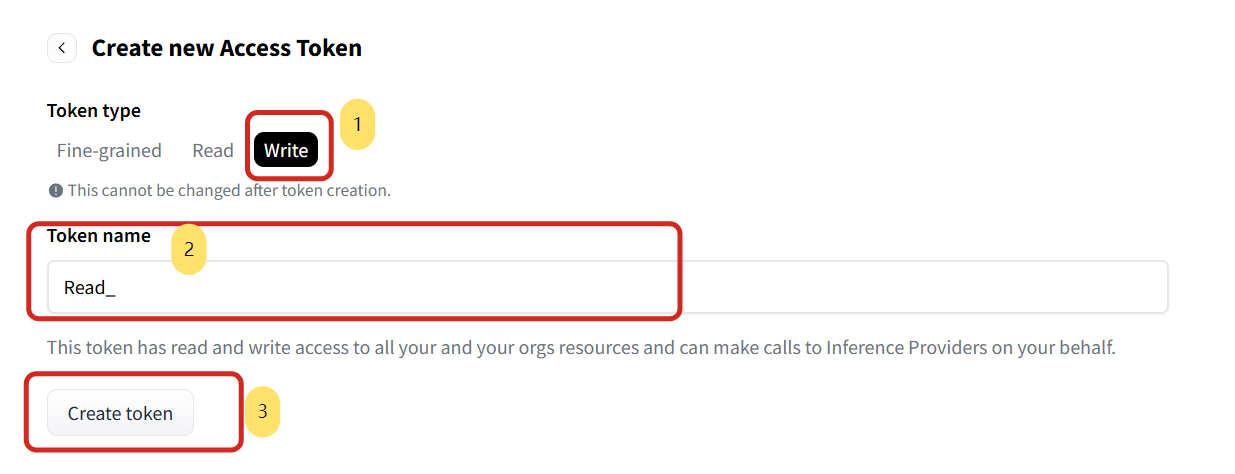

Then copy the token and paste below:

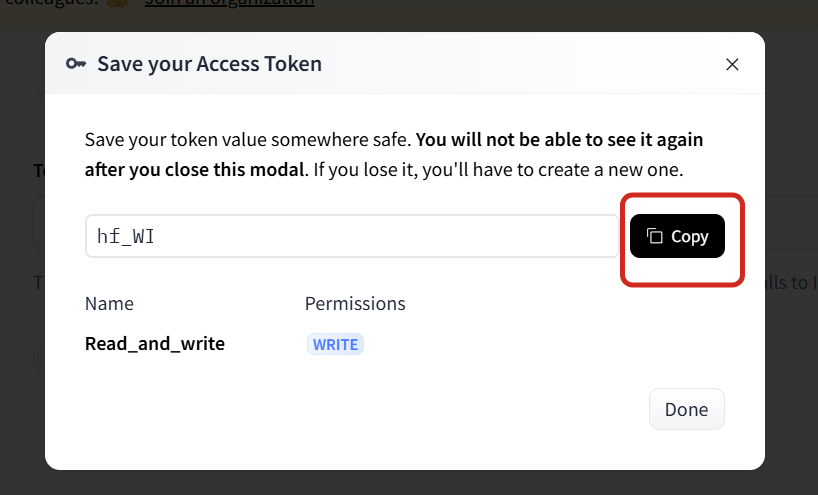

#### Then downloaded the pretrained models first, don't forget to **replace your huggingface token**

In [ ]:
import os
from huggingface_hub import snapshot_download

# Please set your Hugging Face token here first, and set access, you can get your token from https://huggingface.co/settings/tokens
token = "Your_Hugging_Face_Token"  # Replace with your actual token
# set the local directory to save the model
local_dir = "models/"
snapshot_download(repo_id="Zeyu0102/EMCFsys_models", repo_type="model",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, resume_download=True,
                  token=token,
                  max_workers=1)


## Train the segmentation model using the downloaded dataset

#### download the plant organelle segmentation dataset

In [ ]:
import os
from huggingface_hub import snapshot_download

# Please set your Hugging Face token here first, and set access, you can get your token from https://huggingface.co/settings/tokens


# token = "Your Hugging Face token here"
local_dir = "datasets_temp/plantsegdataset"
# 使用cache_dir参数，将模型/数据集保存到指定“本地路径”
snapshot_download(repo_id="Zeyu0102/EMCF_PlantSegDataset", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True,
                  token=token)

# plantsegdataset.zip

import zipfile
# unzip the downloaded dataset
import os
zip_file = zipfile.ZipFile(os.path.join(local_dir, "plantsegdataset.zip"), 'r')

# 遍历压缩包内的所有文件并解压到当前目录
dataset_dir = os.path.join(local_dir, "plantsegdataset")
for file in zip_file.namelist():
   zip_file.extract(file, local_dir) # 解压到当前目录
zip_file.close()

print("Plant Organelle segmentation Dataset downloaded and unzipped successfully.")

Train EMCFsys model based MAE using UperNet as segmentation Head

In [ ]:
from mmengine import Config

cfg = Config.fromfile(r'configs\SemanticSegmentation\MAE_EMCF_UPerNet.py')

cfg.load_from = r'models\MAE_backbone_mmbackend.pth'
cfg.data_root = r'datasets_temp\plantsegdataset'

# check the batch size of the training dataloader, if it is too large, you can reduce it to avoid out of memory error
# cfg.train_dataloader.batch_size = 8

from mmengine.runner import Runner
runner = Runner.from_cfg(cfg)
# start training
runner.train()

Train the EMCFsys model based Dinov3

In [ ]:
from mmengine import Config

cfg = Config.fromfile(r'configs\SemanticSegmentation\DinoV3_UperNet.py')

cfg.load_from = r'models\Dinov3_backbone_mmbackend.pth'
cfg.data_root = r'datasets_temp\plantsegdataset'
from mmengine.runner import Runner
runner = Runner.from_cfg(cfg)
# start training
runner.train()

## For instance task

#### Instance dataset

In [ ]:
import os
from huggingface_hub import snapshot_download

# Please set your Hugging Face token here first, and set access, you can get your token from https://huggingface.co/settings/tokens
# token = "Your Hugging Face token here"
local_dir = "datasets_temp/MitoInstanceSegDataset"
# 使用cache_dir参数，将模型/数据集保存到指定“本地路径”
snapshot_download(repo_id="Zeyu0102/EMCFsys_MitoInstanceSegDataset", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True,
                  token=token
                  )

print("Plant Organelle segmentation Dataset downloaded and unzipped successfully.")

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 28 files:   0%|          | 0/28 [00:00<?, ?it/s]

Plant Organelle segmentation Dataset downloaded and unzipped successfully.


## For classification Task

#### Download the Classification Dataset

In [ ]:
import os
from huggingface_hub import snapshot_download

# Please set your Hugging Face token here first, and set access, you can get your token from https://huggingface.co/settings/tokens

# token = "Your Hugging Face token here"
local_dir = "datasets_temp/EightOrganelleClassification"
snapshot_download(repo_id="Zeyu0102/EightOrganelleClassification", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True,
                  token=token)


import zipfile
# unzip the downloaded dataset
import os
zip_file = zipfile.ZipFile(os.path.join(local_dir, "OrganelleClassifyDataset.zip"), 'r')

dataset_dir = os.path.join(local_dir, "EightOrganelleClassification")
for file in zip_file.namelist():
   zip_file.extract(file, local_dir) 
zip_file.close()

print("Plant Organelle segmentation Dataset downloaded and unzipped successfully.")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

'D:\\napari_EMCF\\EMCFsys\\emcfsys\\datasets_temp\\EightOrganelleClassification'

#### train the KNN model use EMCellFound model(trianed by MAE and DinoV3)

##### EMCellFound_MAE

In [1]:
from demo.KNN_code.KNN import run_knn_classification

knn_result = run_knn_classification(
    dataset_dir="datasets_temp/EightOrganelleClassification/OrganelleClassifyDataset",
    save_dir="save_logs/EMCellFound_MAE_KNN",
    backbone_name="emcellfound_vit_base",
    folds=5,
    k=5,
    device="auto",
)
knn_result

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Dataset: datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset
Train pool: 1790 images
Held-out test set: 446 images
Classes (8): Autosome, CellWall, Chloroplast, ER, Golgi, Mito, Nucleus, Vesicles
Device: cuda
KNN uses deterministic resize + normalization without random augmentation.
Pretrained weights loaded successfully.
[EMCellFound Model] Downloading pretrained model via torch.hub:
  https://github.com/yzy0102/emcfsys/releases/latest/download/MAE_EMCellFoundVit_base_224_inEMCF.pth
[EMCellFound] missing keys: ['head.weight', 'head.bias']
[EMCellFound] unexpected keys: []
[EMCellFound] Loading pretrained weights from project model cache: D:\napari_EMCF\EMCFsys\emcfsys\models\MAE_EMCellFoundVit_base_224_inEMCF.pth
Pretrained weights loaded successfully.

Fold 1/5


D:\napari_EMCF\EMCFsys\emcfsys\src\emcfsys\EMCellFound\models\classifier.py:144: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  similarity = torch.mm(test_features, train_features.t())


Fold metrics: accuracy=0.9583, macro_f1=0.9587

Fold 2/5
Fold metrics: accuracy=0.9556, macro_f1=0.9544

Fold 3/5
Fold metrics: accuracy=0.9389, macro_f1=0.9298

Fold 4/5
Fold metrics: accuracy=0.9380, macro_f1=0.9325

Fold 5/5
Fold metrics: accuracy=0.9549, macro_f1=0.9525

5-fold CV summary: accuracy=0.9491±0.0088, macro_f1=0.9456±0.0120

Fitting final KNN on the full 80% train pool...
Held-out test metrics: accuracy=0.9686, macro_f1=0.9645

Saved fold metrics: save_logs\EMCellFound_MAE_KNN\fold_metrics.csv
Saved CV metrics: save_logs\EMCellFound_MAE_KNN\cv_metrics.json
Saved test metrics: save_logs\EMCellFound_MAE_KNN\test_metrics.json
Saved test predictions: save_logs\EMCellFound_MAE_KNN\test_predictions.csv
Saved final KNN checkpoint: save_logs\EMCellFound_MAE_KNN\classification_knn_cv_final.pth


{'cv_summary': {'accuracy_mean': 0.9491471048513302,
  'accuracy_std': 0.008806290394511456,
  'macro_f1_mean': 0.9455753323324665,
  'macro_f1_std': 0.011959008730416686},
 'test_metrics': {'accuracy': 0.968609865470852,
  'macro_precision': 0.9632211538461538,
  'macro_recall': 0.9680577324973877,
  'macro_f1': 0.9644868450039157,
  'per_class': [{'class': 'Autosome',
    'precision': 0.8571428571428571,
    'recall': 1.0,
    'f1': 0.923076923076923,
    'support': 36},
   {'class': 'CellWall',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 99},
   {'class': 'Chloroplast',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 61},
   {'class': 'ER',
    'precision': 0.9333333333333333,
    'recall': 0.9333333333333333,
    'f1': 0.9333333333333333,
    'support': 60},
   {'class': 'Golgi',
    'precision': 0.9807692307692307,
    'recall': 0.8793103448275862,
    'f1': 0.9272727272727272,
    'support': 58},
   {'class': 'Mito',
    'precisio

##### EMCellFound_dinov3

In [1]:
from demo.KNN_code.KNN import run_knn_classification

knn_result = run_knn_classification(
    dataset_dir="datasets_temp/EightOrganelleClassification/OrganelleClassifyDataset",
    save_dir="save_logs/EMCellFound_Dinov3_KNN",
    backbone_name="EmcellFound_dinov3_vit_base",
    # backbone_name="emcellfound_vit_base",
    folds=5,
    k=5,
    device="auto",
)
knn_result

c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Dataset: datasets_temp\EightOrganelleClassification\OrganelleClassifyDataset
Train pool: 1790 images
Held-out test set: 446 images
Classes (8): Autosome, CellWall, Chloroplast, ER, Golgi, Mito, Nucleus, Vesicles
Device: cuda
KNN uses deterministic resize + normalization without random augmentation.
DINOv3Backbone loading pretrained weights from: https://github.com/yzy0102/emcfsys/releases/download/EMCFsys/DinoV3_EMCellFound_ViT_base.pth
DINOv3Backbone loaded https://github.com/yzy0102/emcfsys/releases/download/EMCFsys/DinoV3_EMCellFound_ViT_base.pth: missing_keys=0, unexpected_keys=0

Fold 1/5


D:\napari_EMCF\EMCFsys\emcfsys\src\emcfsys\EMCellFound\models\dinov3.py:157: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, masked_bias)
D:\napari_EMCF\EMCFsys\emcfsys\src\emcfsys\EMCellFound\models\classifier.py:144: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministi

Fold metrics: accuracy=0.9778, macro_f1=0.9772

Fold 2/5
Fold metrics: accuracy=0.9778, macro_f1=0.9792

Fold 3/5
Fold metrics: accuracy=0.9833, macro_f1=0.9805

Fold 4/5
Fold metrics: accuracy=0.9746, macro_f1=0.9749

Fold 5/5
Fold metrics: accuracy=0.9690, macro_f1=0.9664

5-fold CV summary: accuracy=0.9765±0.0047, macro_f1=0.9756±0.0050

Fitting final KNN on the full 80% train pool...
Held-out test metrics: accuracy=0.9843, macro_f1=0.9838

Saved fold metrics: save_logs\EMCellFound_Dinov3_KNN\fold_metrics.csv
Saved CV metrics: save_logs\EMCellFound_Dinov3_KNN\cv_metrics.json
Saved test metrics: save_logs\EMCellFound_Dinov3_KNN\test_metrics.json
Saved test predictions: save_logs\EMCellFound_Dinov3_KNN\test_predictions.csv
Saved final KNN checkpoint: save_logs\EMCellFound_Dinov3_KNN\classification_knn_cv_final.pth


{'cv_summary': {'accuracy_mean': 0.9765101721439748,
  'accuracy_std': 0.004678217851129988,
  'macro_f1_mean': 0.9756372282412761,
  'macro_f1_std': 0.00501884104374847},
 'test_metrics': {'accuracy': 0.984304932735426,
  'macro_precision': 0.9838840996168583,
  'macro_recall': 0.9838840996168583,
  'macro_f1': 0.9838159133709982,
  'per_class': [{'class': 'Autosome',
    'precision': 0.9722222222222222,
    'recall': 0.9722222222222222,
    'f1': 0.9722222222222222,
    'support': 36},
   {'class': 'CellWall',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 99},
   {'class': 'Chloroplast',
    'precision': 1.0,
    'recall': 1.0,
    'f1': 1.0,
    'support': 61},
   {'class': 'ER',
    'precision': 0.9655172413793104,
    'recall': 0.9333333333333333,
    'f1': 0.9491525423728815,
    'support': 60},
   {'class': 'Golgi',
    'precision': 0.9333333333333333,
    'recall': 0.9655172413793104,
    'f1': 0.9491525423728815,
    'support': 58},
   {'class': 'Mito'